In [1]:
pip install langgraph langchain_core langchain_groq tavily-python langchain gradio langchain_community

Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import Dict, TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain.tools import Tool

from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
from dotenv import load_dotenv
import os
import uuid

import sys

from langchain.output_parsers import StructuredOutputParser, ResponseSchema

from langchain_community.tools.tavily_search import TavilySearchResults
from tavily import TavilyClient
from langchain.schema.runnable import RunnableLambda




# Load environment variables and set OpenAI API key
load_dotenv()
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')

In [3]:
class RealEstateSearchState(TypedDict):
    query: str
    preferences: Optional[Dict]
    results: Optional[list]
    final: Optional[Dict]

In [4]:
model_name = "llama-3.1-8b-instant"

In [5]:


def search(state: RealEstateSearchState) -> RealEstateSearchState:
    """search for average house price, cost of living, commute time in area."""
    """agent outputs a bunch of viable real estate in the given budget/county/crime rate/commute time etc"""
    query = state["query"][:800]

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a real estate assistant. Format the user's query for an optimized property search. in a 400 words or less"),
        ("user", f"Query: {query}")
    ])

    chain = prompt | ChatGroq(model=model_name, temperature=0, max_tokens= 800)
    refined_query = chain.invoke({"query": query}).content

    if len(refined_query) > 800:
        refined_query = refined_query[:397].rsplit(" ", 1)[0] + "..."
    state["preferences"] = {"refined_query": refined_query}

    # Run Tavily search using refined query
    search_results = tavily_client.search(
        query=refined_query,
        include_domains=["zillow.com/homedetails"],
        max_results=3
    )

    state["results"] = search_results
    return state


In [13]:


def format_search(state: RealEstateSearchState) -> RealEstateSearchState:
    """Format the search results to describe the top three houses in a more easily to read manner."""
    results = state["results"].get("results", [])
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", """You have found the user's houses. You will now format them in a more readle manner do not include anything like: Here are the user's search results formatted in a more readable manner:
            include these things if relvent:
            crime rate
            price
            property type,
            how nice it is
            commute to uptown
            school district
            features
            etc"""),
            ("user", "Here are the search results: {results}"),

        ]
    )
    
    chain = prompt | ChatGroq(model=model_name, temperature=0.3)
    response = chain.invoke({"results": results})
    

    state["final"] = response.content
    return state


In [14]:
agent1 = StateGraph(RealEstateSearchState)

# Add your function nodes
agent1.add_node("search", search)
agent1.add_node("format_search", format_search)


# Set entry point
agent1.set_entry_point("search")

# Define execution order

agent1.add_edge("search", "format_search")
agent1.add_edge("format_search", END)

# Compile it into a runnable chain
agent1 = agent1.compile()

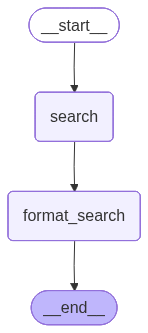

In [15]:
display(
    Image(
        agent1.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [16]:
sample_user_1 = """I would like a house in NC that has three bedrooms with low crime rate, and has great schools, cost around 50000 on zillow """

In [17]:
initial_state = {
    "query": sample_user_1,
    "preferences": None,
    "results": None,
    "final": None
}

result = agent1.invoke(initial_state)

In [18]:
final_results = result.get("final")
#print(result)
print(final_results)

**Search Results for Homes in Greensboro and Raleigh, NC**

### 1. 1606 Sharpe Rd, Greensboro, NC 27406

* **Property Type:** Single Family Home
* **Size:** 1973 sq ft
* **Year Built:** 1938
* **Bedrooms:** 3
* **Bathrooms:** 2
* **Last Sold Price:** $267,500 (June 2025)
* **Current Zestimate:** $267,600
* **Price Change:** Decreased by $1,007 in the last 30 days
* **Commute to Uptown:** Not specified
* **School District:** Not specified
* **Features:** Not specified

### 2. Undisclosed Address, Raleigh, NC 27601

* **Property Type:** Single Family Home
* **Size:** 1881 sq ft
* **Bedrooms:** 3
* **Bathrooms:** 2
* **Neighborhood:** North Central
* **Commute to Uptown:** Not specified
* **School District:** Not specified
* **Features:** Not specified

### 3. 3001 Idlewood Village Dr, Raleigh, NC 27610

* **Property Type:** Single Family Home
* **Size:** Not specified
* **Bedrooms:** 3
* **Bathrooms:** Not specified
* **Features:**
	+ Covered Front Porch
	+ Updated Fixtures
	+ Garage/Sto

User Interface and Agent Response:

Final response of the agent should be well structured into a report (pdf format).

A user interface where the user can ask a query and get the response from the LLM, a report that can be downloaded or viewed in the interface.

In [12]:
import streamlit as st
import random
import time

st.write("Streamlit loves LLMs! 🤖 [Build your own chat app](https://docs.streamlit.io/develop/tutorials/llms/build-conversational-apps) in minutes, then make it powerful by adding images, dataframes, or even input widgets to the chat.")

st.caption("Note that this demo app isn't actually connected to any LLMs. Those are expensive ;)")

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = [{"role": "assistant", "content": "Let's start chatting! 👇"}]

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Accept user input
if prompt := st.chat_input("What is up?"):
    # Add user message to chat history
    st.session_state.messages.append({"role": "user", "content": prompt})
    # Display user message in chat message container
    with st.chat_message("user"):
        st.markdown(prompt)

    # Display assistant response in chat message container
    with st.chat_message("assistant"):
        message_placeholder = st.empty()
        full_response = ""
        assistant_response = random.choice(
            [
                "Hello there! How can I assist you today?",
                "Hi, human! Is there anything I can help you with?",
                "Do you need help?",
            ]
        )
        # Simulate stream of response with milliseconds delay
        for chunk in assistant_response.split():
            full_response += chunk + " "
            time.sleep(0.05)
            # Add a blinking cursor to simulate typing
            message_placeholder.markdown(full_response + "▌")
        message_placeholder.markdown(full_response)
    # Add assistant response to chat history
    st.session_state.messages.append({"role": "assistant", "content": full_response})


2025-10-15 15:45:12.940 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.304 
  command:

    streamlit run C:\Users\ericm\anaconda3\envs\langchain\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-15 15:45:14.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-15 15:45:14.309 Thread '